In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

***Tarea 2. Modelo de depreciación de un automóvil.***

Un automóvil nuevo tiene un valor inicial de $V_{0}=320000$ pesos. Se estima que cada año pierde el $15\%$ de su valor respecto al año anterior.

Este fenómeno puede modelarse con:
$$V_{t+1}=V_{t}(1-d)$$
donde:



*   $V_{t}$ es el valor del automóvil en el año $t$
*   $d$ es la tasa de depreciación anual
*   $t$ representa el tiempo en años.




Expresemos de diferente manera la ecuación de recurrencia del modelo, para poder programarla de manera más fácil y efiiciente. Lo que haremos será tomar distintos valores de $t$.

Si $t=0$ tenemos $V_{1}=V_{0}(1-d)$

Si $t=1$ tenemos $V_{2}= V_{1}(1-d)=(V_{0}(1-d))(1-d)=V_{0}(1-d)^2$, entonces
$$V_{2}=V_{0}(1-d)^{2}$$

Si $t=2$ tenemos $V_{3}= V_{2}(1-d)=(V_{0}(1-d)^{2})(1-d)=V_{0}(1-d)^3$, entonces
$$V_{2}=V_{0}(1-d)^{3}$$

Usando inducción matemática se prueba que
$$V_{t}=V_{0}(1-d)^{t}$$

***Solución del problema:***

In [ ]:
# Datos del problema
V0 = 320000 #precio inicial
d = 0.15 #tasa de depresiación anual
años = 15 #número de años

precios = []

for t in range(años + 1):
  V = V0 * (1 - d)**t
  precios.append(V)

precios

[320000.0,
 272000.0,
 231199.99999999997,
 196519.99999999997,
 167041.99999999997,
 141985.69999999998,
 120687.84499999997,
 102584.66824999997,
 87196.96801249999,
 74117.42281062498,
 62999.80938903123,
 53549.837980676544,
 45517.362283575065,
 38689.757941038806,
 32886.29424988298,
 27953.350112400534]

In [ ]:
df = pd.DataFrame({
    "Año": range(años + 1),
    "Valor del automóvil": precios
})

df

,Año,Valor del automóvil
0,0,320000.000000
1,1,272000.000000
2,2,231200.000000
3,3,196520.000000
4,4,167042.000000
5,5,141985.700000
6,6,120687.845000
7,7,102584.668250
8,8,87196.968012
9,9,74117.422811


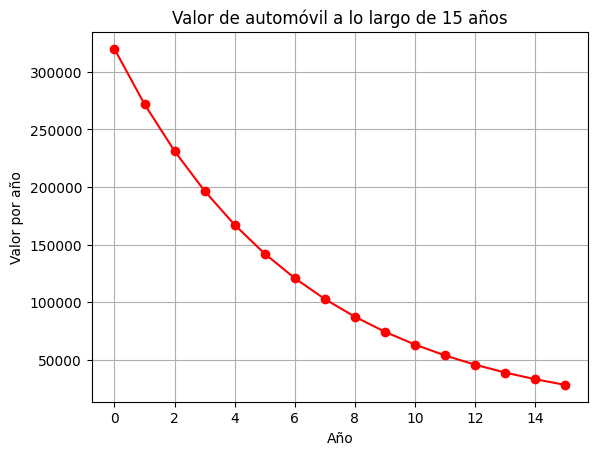

In [ ]:
# gráfica del valor del automóvil, en función del tiempo.

plt.plot(df["Año"], df["Valor del automóvil"], marker="o", color='red')
plt.xlabel("Año")
plt.ylabel("Valor por año")
plt.title("Valor de automóvil a lo largo de 15 años")
plt.grid()
plt.show()

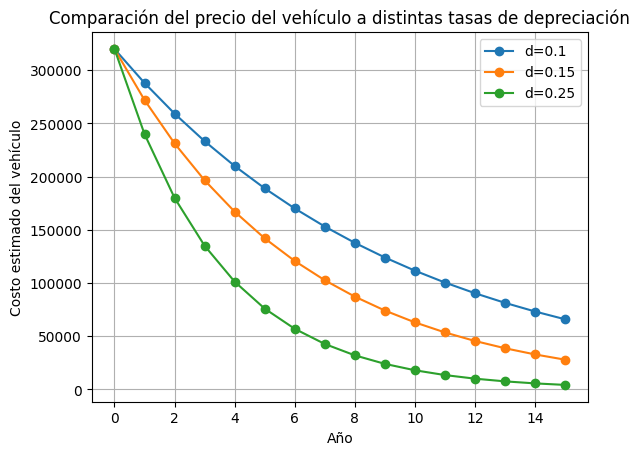

In [ ]:
# Consideremos tres tasas de depreciación
# y simulemos nuevamente el modelo.

tasas = [0.10, 0.15, 0.25]

for d in tasas:
  precios = []
  for t in range(años + 1):
    V = V0 * (1 - d)**t
    precios.append(V)
  plt.plot(range(años + 1), precios, marker="o", label=f"d={d}")

plt.xlabel("Año")
plt.ylabel("Costo estimado del vehículo")
plt.title("Comparación del precio del vehículo a distintas tasas de depreciación")
plt.legend()
plt.grid()
plt.show()


**Preguntas:**

1.-¿Qué representa el parámetro $d$?

R: El parámetro $d$ representa la tasa de depreciación anual, es decir, que porcentaje va disminuyendo el precio del automóvil.

2.-¿Qué ocurre con el valor del automóvil cuando aumenta $d$?

R: Cuando el valor de la tasa de depreciasión anual $d$ aumenta el valor del automóvil desciende más rápido, es decir, el automóvil pierde mucho valor monetario en poco tiempo.

3.-¿El valor del automóvil llega exactamente a $0$?

R: El valor del automóvil llegaría exactamente a $0$ pesos si consederamos una tasa de depreciación anual del $100\%$, es decir $d=1$ así en el modelo
$$V_{t+1}=V_{t}(1-d)$$
obtendríamos que $V=0$, pues $1-d=1-1=0$. Pero si la tasa de depreciación es menor al $100\%$, es decir $d<1$ el valor del automóvil nunca llegará exactamente a $0$ pesos pues $1-d>0$, por lo que, el valor del automóvil siempre será distinto de cero. De manera más formal, en el caso límite si $0<d<1$ tenemos que
$$\lim_{t \rightarrow \infty}V_{0}(1-d)^{t}=0$$

es decir, el valor del vehículo si tiende acero pero no lo hace en un tiempo finito.

4.-¿Depués de cuántos años el automóvil vale menos de la mitad de su valor inicial cuando $d=0.15$?

R: Según lo observado en la gráfica, cuando $d=0.15$, a partir del quinto año el valor del automóvil está por debajo de la mitad de su precio original. Podemos verificar de manera analítica: queremos ver el valor de $t$ tal que
$$V_{t}<\frac{V_{0}}{2}$$
esto implica que $V_{0}(1-d)^{t}<\frac{V_{0}}{2}$, cancelando $V_{0}$ se tiene
$$(1-d)^{t}<\frac{1}{2}$$
con $d=0.15$ se tiene que
$$(0.85)^{t}<\frac{1}{2}$$
al aplicar logaritmo natural se tiene que $t \operatorname{ln}(0.85)> \operatorname{ln}(0.5)$, por lo que
$$t>\frac{\operatorname{ln}(0.5)}{\operatorname{ln}(0.85)} \approx 4.27 \text{ años}$$
por lo que en efecto, podríamos decir que a partir del quinto año, el valor original del coche ya está por debajo de la mitad.

5.-¿Qué limitaciones tiene este modelo en la vida real?

R: Pues este modelo no considera otros detalles que hacen que el valor del auto también se devalúe, por ejemplo el estado de los interiores, la pintura, el estado del motor, si tiene multas, la inflación, la oferta / demanda que tenga el vehículo, etc. Entonces este modelo en efecto nos ayuda a aproximar un valor del vehículo, sin embargo en muchos casos el valor estimado aproximado estará por encima del valor real si es que se consideraran los detalles antes mencionados.